In [1]:
#diffusers is a hugging face page for using diffusion models from huggingface hub
!pip install diffusers transformers gradio accelerate

In [2]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
!pip show torch

Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision


In [4]:
model_id1 = "dreamlike-art/dreamlike-diffusion-1.0"
model_id2 = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionPipeline.from_pretrained(model_id1, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [5]:
prompt = """an advertisment that shows the phone  and its new feature like fast internet, fast calling, good camera
"""

In [10]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

[PROMPT]:  an advertisment that shows the phone  and its new feature like fast internet, fast calling, good camera



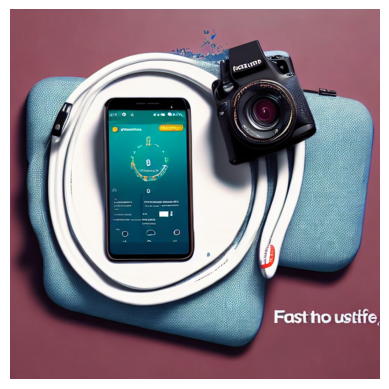

In [11]:
print("[PROMPT]: ",prompt)
plt.imshow(image);
plt.axis('off');

### Working with Stable Diffusion parameters

* Negative prompting
* num_inference_steps
* height
* weight
* num_images_per_prompt

In [7]:
def generate_image(pipe, prompt, params):
  img = pipe(prompt, **params).images

  num_images = len(img)
  if num_images>1:
    fig, ax = plt.subplots(nrows=1, ncols=num_images)
    for i in range(num_images):
      ax[i].imshow(img[i]);
      ax[i].axis('off');

  else:
    fig = plt.figure()
    plt.imshow(img[0]);
    plt.axis('off');
  plt.tight_layout()

In [12]:
prompt = "dreamlike a poster of advertisment,Written {AMUL MILK} in it."

params = {}

  0%|          | 0/100 [00:00<?, ?it/s]

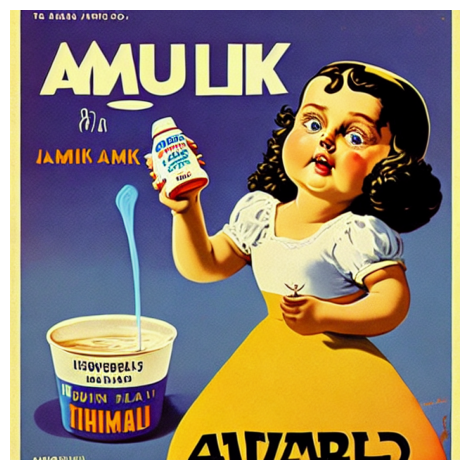

In [13]:
#num inference steps
params = {'num_inference_steps': 100}

generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

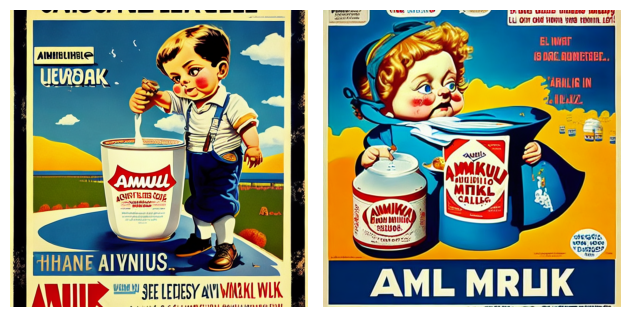

In [14]:
#num_images_per_prompt
params = {'num_inference_steps': 100, 'num_images_per_prompt': 2}

generate_image(pipe, prompt, params)

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[PROMPT]: an advertisement that shows the phone and its new feature like fast internet, fast calling, good camera


  0%|          | 0/50 [00:00<?, ?it/s]

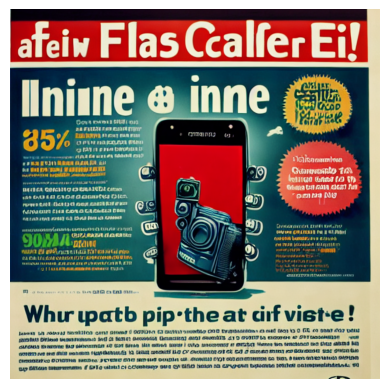

In [15]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

# Model IDs
model_id1 = "dreamlike-art/dreamlike-diffusion-1.0"
model_id2 = "stabilityai/stable-diffusion-xl-base-1.0"

# Load pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_id1, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to("cuda")

# Define prompt
prompt = """an advertisement that shows the phone and its new feature like fast internet, fast calling, good camera"""

print("[PROMPT]:", prompt)

# Generate image
image = pipe(prompt).images[0]

# Display image
plt.imshow(image)
plt.axis('off')
plt.show()


In [16]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 104.7 MB/s eta 0:00:00


##front end


In [17]:
%%writefile app.py
import streamlit as st
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

# Load model
@st.cache_resource
def load_pipeline(model_id):
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, use_safetensors=True)
    return pipe.to("cuda")

model_id = "dreamlike-art/dreamlike-diffusion-1.0"
pipe = load_pipeline(model_id)

def generate_image(pipe, prompt, num_inference_steps, num_images_per_prompt):
    params = {'num_inference_steps': num_inference_steps, 'num_images_per_prompt': num_images_per_prompt}
    images = pipe(prompt, **params).images

    # Display images in Streamlit
    num_images = len(images)
    if num_images > 1:
        fig, ax = plt.subplots(1, num_images, figsize=(10, 5))
        for i in range(num_images):
            ax[i].imshow(images[i])
            ax[i].axis('off')
    else:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(images[0])
        ax.axis('off')
    st.pyplot(fig)

# Streamlit UI
st.title("Stable Diffusion Image Generation")

# User input for prompt and parameters
prompt = st.text_input("Enter your prompt:", "dreamlike a poster of advertisement, Written {AMUL MILK} in it.")
num_inference_steps = st.slider("Number of Inference Steps", min_value=1, max_value=150, value=100)
num_images_per_prompt = st.slider("Number of Images per Prompt", min_value=1, max_value=4, value=1)

if st.button("Generate Image"):
    with st.spinner("Generating..."):
        generate_image(pipe, prompt, num_inference_steps, num_images_per_prompt)


Writing app.py


In [18]:
!pip install streamlit diffusers torch matplotlib


In [19]:
!wget -q -O - ipv4.icanhazip.com

34.143.153.72


In [20]:
!npm install -g localtunnel@2.0.2

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 2s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴npm notice
npm notice New major version of npm available! 10.8.2 -> 11.18.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.18.0
npm notice To update run: npm install -g npm@11.18.0
npm notice
⠴

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹

your url is: https://great-coins-show.loca.lt
2026-07-07 19:17:57.256 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.143.153.72:8501

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline components...:   0% 0/5 [00:00<?, ?it/s]
Loading weights: 100% 196/196 [00:00<00:00, 23754.84it/s]
Loading pipeline components...: 100% 5/5 [00:00<00:00,  9.51it/s]
100% 100/100 [00:28<00:00,  3.49it/s]


# ***flask app***

In [ ]:
!pip install flask pyngrok


In [ ]:
!pip install flask pyngrok diffusers transformers accelerate safetensors torch matplotlib


In [ ]:
!pip install flask flask-login


In [ ]:
%%writefile app.py
from flask import Flask, request, render_template
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt
import os
import uuid

app = Flask(__name__)

model_id = "dreamlike-art/dreamlike-diffusion-1.0"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to("cuda")

@app.route("/", methods=["GET", "POST"])
def index():
    image_paths = []
    if request.method == "POST":
        prompt = request.form["prompt"]
        num_steps = int(request.form["steps"])
        num_images = int(request.form["count"])

        images = pipe(prompt, num_inference_steps=num_steps, num_images_per_prompt=num_images).images

        for img in images:
            filename = f"static/{uuid.uuid4().hex}.png"
            img.save(filename)
            image_paths.append(filename)

    return render_template("index.html", image_paths=image_paths)

if __name__ == "__main__":
    app.run()


In [ ]:
!mkdir -p templates static


In [ ]:
%%writefile templates/index.html
<!DOCTYPE html>
<html>
<head>
    <title>Ad Poster Maker</title>
    <style>
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #e3f2fd, #bbdefb);
            margin: 0;
            padding: 0;
            text-align: center;
            animation: fadeIn 1s ease-in-out;
        }

        @keyframes fadeIn {
            from { opacity: 0; transform: translateY(20px); }
            to { opacity: 1; transform: translateY(0); }
        }

        h2 {
            color: #333;
            padding: 20px;
        }

        .form-container {
            background: white;
            display: inline-block;
            padding: 30px 40px;
            border-radius: 15px;
            box-shadow: 0 10px 25px rgba(0, 0, 0, 0.1);
            margin-top: 20px;
            animation: slideIn 0.7s ease-in-out;
        }

        @keyframes slideIn {
            from { transform: scale(0.95); opacity: 0; }
            to { transform: scale(1); opacity: 1; }
        }

        label {
            font-weight: bold;
            display: block;
            margin-top: 15px;
            margin-bottom: 5px;
            color: #333;
        }

        input {
            padding: 10px;
            width: 300px;
            border: 1px solid #ccc;
            border-radius: 8px;
            margin-bottom: 10px;
            font-size: 15px;
        }

        input:focus {
            border-color: #007BFF;
            box-shadow: 0 0 5px rgba(0, 123, 255, 0.3);
            outline: none;
        }

        button {
            padding: 12px 25px;
            background: #007BFF;
            color: white;
            border: none;
            border-radius: 8px;
            font-size: 16px;
            cursor: pointer;
            margin-top: 15px;
            transition: background 0.3s ease;
        }

        button:hover {
            background: #0056b3;
        }

        .poster-gallery {
            margin-top: 40px;
            animation: fadeIn 1s ease-in-out;
        }

        .poster-gallery h3 {
            margin-bottom: 20px;
            color: #444;
        }

        .poster {
            display: inline-block;
            margin: 15px;
            background: #fff;
            padding: 15px;
            border-radius: 10px;
            box-shadow: 0 5px 20px rgba(0, 0, 0, 0.1);
            transition: transform 0.3s;
        }

        .poster:hover {
            transform: translateY(-5px);
        }

        .poster img {
            width: 300px;
            border-radius: 8px;
        }

        .poster a {
            display: block;
            margin-top: 10px;
            text-decoration: none;
            color: #007BFF;
            font-weight: 500;
        }

        .poster a:hover {
            text-decoration: underline;
        }

        .nav-links {
            margin-top: 25px;
            font-size: 14px;
        }

        .nav-links a {
            margin: 0 10px;
            text-decoration: none;
            color: #007BFF;
        }

        .nav-links a:hover {
            text-decoration: underline;
        }

        .brand {
            font-size: 22px;
            font-weight: bold;
            color: #007BFF;
            margin-top: 20px;
        }
    </style>
</head>
<body>
    <div class="brand">🎨 Ad Poster Maker</div>
    <h2>Welcome{% if current_user.is_authenticated %}, {{ current_user.id }}{% endif %}!</h2>

    {% if current_user.is_authenticated %}
        <div class="form-container">
            <form method="post">
                <label>Prompt:</label>
                <input type="text" name="prompt" placeholder="e.g. A colorful ad poster for AMUL Milk" required><br>

                <label>Inference Steps:</label>
                <input type="number" name="steps" value="50" min="1" max="150" required><br>

                <label>Number of Posters:</label>
                <input type="number" name="count" value="1" min="1" max="4" required><br>

                <button type="submit">✨ Generate Poster</button>
            </form>
        </div>

        {% if image_paths %}
            <div class="poster-gallery">
                <h3>Generated Posters:</h3>
                {% for img in image_paths %}
                    <div class="poster">
                        <img src="{{ img }}">
                        <a href="{{ img }}" download>📥 Download</a>
                    </div>
                {% endfor %}
            </div>
        {% endif %}

        <div class="nav-links">
            <a href="/logout">Logout</a>
        </div>
    {% else %}
        <div class="nav-links">
            <a href="/login">Login</a> |
            <a href="/register">Register</a>
        </div>
    {% endif %}
</body>
</html>


In [ ]:
%%writefile templates/login.html
<!DOCTYPE html>
<html>
<head>
    <title>Login | Poster Maker</title>
    <style>
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #e3f2fd, #bbdefb);
            margin: 0;
            padding: 0;
            display: flex;
            align-items: center;
            justify-content: center;
            height: 100vh;
            animation: fadeIn 1s ease-in-out;
        }

        @keyframes fadeIn {
            from { opacity: 0; transform: translateY(20px); }
            to { opacity: 1; transform: translateY(0); }
        }

        .login-box {
            background: white;
            padding: 30px 40px;
            border-radius: 15px;
            box-shadow: 0 10px 25px rgba(0,0,0,0.1);
            text-align: center;
            width: 350px;
        }

        h2 {
            margin-bottom: 20px;
            color: #333;
        }

        input {
            width: 100%;
            padding: 12px;
            margin: 10px 0;
            border: 1px solid #ccc;
            border-radius: 8px;
            box-sizing: border-box;
            font-size: 15px;
        }

        input:focus {
            border-color: #007BFF;
            box-shadow: 0 0 5px rgba(0,123,255,0.3);
            outline: none;
        }

        button {
            width: 100%;
            padding: 12px;
            background-color: #007BFF;
            color: white;
            border: none;
            border-radius: 8px;
            font-size: 16px;
            cursor: pointer;
            transition: background 0.3s ease;
        }

        button:hover {
            background-color: #0056b3;
        }

        a {
            display: inline-block;
            margin-top: 15px;
            text-decoration: none;
            color: #007BFF;
            font-size: 14px;
        }

        a:hover {
            text-decoration: underline;
        }

        .brand {
            font-size: 18px;
            color: #555;
            margin-bottom: 15px;
            font-style: italic;
        }
    </style>
</head>
<body>
    <div class="login-box">
        <div class="brand">🎨 Poster Maker App</div>
        <h2>Login</h2>
        <form method="post">
            <input name="username" placeholder="Username" required>
            <input name="password" type="password" placeholder="Password" required>
            <button type="submit">Login</button>
        </form>
        <a href="/register">Don't have an account? Register</a>
    </div>
</body>
</html>


In [ ]:
%%writefile templates/register.html
<!DOCTYPE html>
<html>
<head>
    <title>Register | Poster Maker</title>
    <style>
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #e3f2fd, #bbdefb);
            margin: 0;
            padding: 0;
            display: flex;
            align-items: center;
            justify-content: center;
            height: 100vh;
            animation: fadeIn 1s ease-in-out;
        }

        @keyframes fadeIn {
            from { opacity: 0; transform: translateY(20px); }
            to { opacity: 1; transform: translateY(0); }
        }

        .register-box {
            background: white;
            padding: 30px 40px;
            border-radius: 15px;
            box-shadow: 0 10px 25px rgba(0,0,0,0.1);
            text-align: center;
            width: 350px;
        }

        h2 {
            margin-bottom: 20px;
            color: #333;
        }

        input {
            width: 100%;
            padding: 12px;
            margin: 10px 0;
            border: 1px solid #ccc;
            border-radius: 8px;
            box-sizing: border-box;
            font-size: 15px;
        }

        input:focus {
            border-color: #007BFF;
            box-shadow: 0 0 5px rgba(0,123,255,0.3);
            outline: none;
        }

        button {
            width: 100%;
            padding: 12px;
            background-color: #007BFF;
            color: white;
            border: none;
            border-radius: 8px;
            font-size: 16px;
            cursor: pointer;
            transition: background 0.3s ease;
        }

        button:hover {
            background-color: #0056b3;
        }

        a {
            display: inline-block;
            margin-top: 15px;
            text-decoration: none;
            color: #007BFF;
            font-size: 14px;
        }

        a:hover {
            text-decoration: underline;
        }

        .brand {
            font-size: 18px;
            color: #555;
            margin-bottom: 15px;
            font-style: italic;
        }
    </style>
</head>
<body>
    <div class="register-box">
        <div class="brand">🎨 Poster Maker App</div>
        <h2>Register</h2>
        <form method="post">
            <input name="username" placeholder="Username" required>
            <input name="password" type="password" placeholder="Password" required>
            <button type="submit">Register</button>
        </form>
        <a href="/login">Already have an account? Login</a>
    </div>
</body>
</html>


In [ ]:
!ngrok config add-authtoken 2vZRV2IiPttDjxd0tBfbA4nkIBj_7hJjTUioXf1qpDaSRo1Nd

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
import os, uuid
import threading, time
from flask import Flask, render_template, request, redirect, url_for
from flask_login import LoginManager, login_user, login_required, logout_user, UserMixin, current_user
from werkzeug.security import generate_password_hash, check_password_hash
from diffusers import StableDiffusionPipeline
import torch

app = Flask(__name__)
app.secret_key = 'your-secret-key'

# ===== User Auth Setup =====
login_manager = LoginManager()
login_manager.init_app(app)
login_manager.login_view = 'login'  # Redirect unauthorized users to login

users = {}

class User(UserMixin):
    def __init__(self, id):
        self.id = id

@login_manager.user_loader
def load_user(user_id):
    if user_id in users:
        return User(user_id)
    return None

@app.route('/register', methods=['GET', 'POST'])
def register():
    if request.method == 'POST':
        username = request.form['username']
        password = generate_password_hash(request.form['password'])
        if username in users:
            return 'Username already exists!'
        users[username] = {'password': password}
        return redirect('/login')
    return render_template('register.html')

@app.route('/login', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        username = request.form['username']
        password = request.form['password']
        user_data = users.get(username)
        if user_data and check_password_hash(user_data['password'], password):
            user = User(username)
            login_user(user)
            return redirect('/')
        return 'Invalid credentials!'
    return render_template('login.html')

@app.route('/logout')
@login_required
def logout():
    logout_user()
    return redirect('/login')

# ===== Stable Diffusion Setup =====
model_id = "dreamlike-art/dreamlike-diffusion-1.0"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to("cuda")

@app.route('/', methods=['GET', 'POST'])
@login_required
def index():
    image_paths = []
    if request.method == "POST":
        prompt = request.form["prompt"]
        steps = int(request.form["steps"])
        count = int(request.form["count"])
        images = pipe(prompt, num_inference_steps=steps, num_images_per_prompt=count).images

        for img in images:
            path = f"static/{uuid.uuid4().hex}.png"
            img.save(path)
            image_paths.append(path)
    return render_template("index.html", image_paths=image_paths)

# ==== Start Flask in thread and expose via ngrok ====
def run_app():
    app.run(port=5000)

threading.Thread(target=run_app).start()
time.sleep(3)

from pyngrok import ngrok
public_url = ngrok.connect(5000)
print(f"🚀 Your Flask app is live: {public_url}/register")


In [ ]:
!pip install flask
!pip install pyngrok


In [ ]:
!ngrok authtoken 2npmDAfSdWo69DiH2I6sMjTm2yf_7zKw72LE5fx4HoMeQUbX6

In [ ]:


# Install FaceNet-PyTorch
!pip install onnxscript





True


In [ ]:
from flask import Flask,render_template,request
app=Flask(__name__,template_folder='/content/templates')

@app.route("/")
def home():
  return render_template("index.html")

if __name__ == "__main__":
  app.run()

In [ ]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

In [ ]:
df.columns

In [ ]:
!pip install transformers datasets accelerate


In [ ]:
df.head()

In [ ]:
print(df_train['content'].iloc[0])
